<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-7/7.6_decision_trees-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/PlayTennis.csv')

print(data.shape)
print(data.head())

(14, 5)
    Outlook Temperature Humidity    Wind Play Tennis
0     Sunny         Hot     High    Weak          No
1     Sunny         Hot     High  Strong          No
2  Overcast         Hot     High    Weak         Yes
3      Rain        Mild     High    Weak         Yes
4      Rain        Cool   Normal    Weak         Yes


In [3]:
print(data.isnull().sum())

Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64


In [4]:
print(data.columns)

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis'], dtype='object')


In [5]:
data['Outlook'] = data['Outlook'].map({
    'Sunny': 0,
    'Overcast': 1,
    'Rain': 2
})

data['Temperature'] = data['Temperature'].map({
    'Hot': 0,
    'Mild': 1,
    'Cool': 2
})

data['Humidity'] = data['Humidity'].map({
    'High': 0,
    'Normal': 1
})

data['Wind'] = data['Wind'].map({
    'Weak': 0,
    'Strong': 1
})

data['Play Tennis'] = data['Play Tennis'].map({
    'No': 0,
    'Yes': 1
})

print(data)

    Outlook  Temperature  Humidity  Wind  Play Tennis
0         0            0         0     0            0
1         0            0         0     1            0
2         1            0         0     0            1
3         2            1         0     0            1
4         2            2         1     0            1
5         2            2         1     1            0
6         1            2         1     1            1
7         0            1         0     0            0
8         0            2         1     0            1
9         2            1         1     0            1
10        0            1         1     1            1
11        1            1         0     1            1
12        1            0         1     0            1
13        2            1         0     1            0


In [6]:
X = data[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = data['Play Tennis']

print(X)
print(y)

    Outlook  Temperature  Humidity  Wind
0         0            0         0     0
1         0            0         0     1
2         1            0         0     0
3         2            1         0     0
4         2            2         1     0
5         2            2         1     1
6         1            2         1     1
7         0            1         0     0
8         0            2         1     0
9         2            1         1     0
10        0            1         1     1
11        1            1         0     1
12        1            0         1     0
13        2            1         0     1
0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: Play Tennis, dtype: int64


In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(11, 4)
(3, 4)
(11,)
(3,)


In [8]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [9]:
y_pred = model.predict(x_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 0 1]


In [10]:
accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy_score)
print("Accuracy in Percentage :", int(accuracy_score * 100), "%")

Accuracy Score : 1.0
Accuracy in Percentage : 100 %


In [11]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[1 0]
 [0 2]]


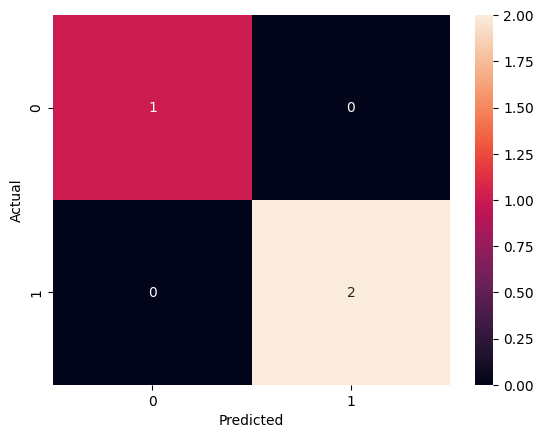

In [12]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)
plt.show()